**Predicting Stock Market Volatility Using Machine Learning and Macroeconomic Indicators**

**1. Installing and importing required libraries for the project.**

In [1]:
!pip install yfinance fredapi arch xgboost shap


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.3/981.3 kB 10.7 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import yfinance as yf
from fredapi import Fred
import matplotlib.pyplot as plt
!pip install arch
from arch import arch_model


from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
from xgboost import XGBRegressor

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.preprocessing import MinMaxScaler

 **2. Data Download and Load**

**DOWNLOAD S&P500 DATA**.                                  Data Link : https://pypi.org/project/yfinance/

In [3]:
sp500 = yf.download("^GSPC", start="2005-01-01", end="2025-01-01")
sp500 = sp500[['Close']]
sp500.dropna(inplace=True)

# Log returns
sp500['log_return'] = np.log(sp500['Close']/sp500['Close'].shift(1))
sp500['volatility'] = sp500['log_return'].rolling(30).std()*np.sqrt(252)
sp500.dropna(inplace=True)

/tmp/ipykernel_2348/1607239576.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  sp500 = yf.download("^GSPC", start="2005-01-01", end="2025-01-01")
[*********************100%***********************]  1 of 1 completed


**Macroeconomic Data (FRED)**

Macroeconomic indicators are retrieved from the Federal Reserve Economic Data (FRED) database using the fredapi.

Get AN API Key
Sign up and request a free API key from FRED:
https://fred.stlouisfed.org/docs/api/api_key.html

In [4]:
fred = Fred(api_key="4b74c73aa90641f62c6f4073c0fc2e36") #THIS IS MY API KEY

cpi = fred.get_series("CPIAUCSL")
unemp = fred.get_series("UNRATE")
interest = fred.get_series("FEDFUNDS")
gdp = fred.get_series("GDP")

macro = pd.concat([cpi, unemp, interest, gdp], axis=1)
macro.columns = ['CPI','Unemployment','InterestRate','GDP']
macro = macro.resample('D').ffill()




**3. Merging Financial + Macroeconomic Data**

In [5]:
if isinstance(sp500.columns, pd.MultiIndex):
    sp500.columns = ['_'.join(col).strip() for col in sp500.columns.values]

data = sp500.join(macro, how='inner')
data.dropna(inplace=True)

print(data.head())

            Close_^GSPC  log_return_  volatility_    CPI  Unemployment  \
2005-04-01  1172.920044    -0.006518     0.109008  193.7           5.2   
2005-04-04  1176.119995     0.002724     0.107511  193.7           5.2   
2005-04-05  1181.390015     0.004471     0.108486  193.7           5.2   
2005-04-06  1184.069946     0.002266     0.100208  193.7           5.2   
2005-04-07  1191.140015     0.005953     0.100389  193.7           5.2   

            InterestRate        GDP  
2005-04-01          2.79  12922.656  
2005-04-04          2.79  12922.656  
2005-04-05          2.79  12922.656  
2005-04-06          2.79  12922.656  
2005-04-07          2.79  12922.656  


**3. Train-Test Split**

In [6]:
X = data[['CPI','Unemployment','InterestRate','GDP']]
y = data['volatility_']

X_train, X_test = X.iloc[:-500], X.iloc[-500:]
y_train, y_test = y.iloc[:-500], y.iloc[-500:]

**4. XGBOOST MODEL (ADVANCED MACHINE LEARNING)**

XGBOOST TRAINING

In [7]:
xgb = XGBRegressor(n_estimators=500, learning_rate=0.05, max_depth=5)
xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)



XGBOOST EVALUATION

In [8]:
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)

print("XGBoost RMSE:", rmse_xgb)
print("XGBoost MAE:", mae_xgb)


XGBoost RMSE: 0.17764756546046917
XGBoost MAE: 0.11837510694771529


**5. LSTM DEEP LEARNING MODEL**

SCALE DATA FOR LSTM

In [9]:
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)
y_scaled = y.values.reshape(-1,1)


CREATE LSTM SEQUENCES

In [10]:
def create_sequences(X, y, step=30):
    Xs, ys = [], []
    for i in range(len(X)-step):
        Xs.append(X[i:i+step])
        ys.append(y[i+step])
    return np.array(Xs), np.array(ys)

X_seq, y_seq = create_sequences(X_scaled, y_scaled)

X_train_lstm, X_test_lstm = X_seq[:-500], X_seq[-500:]
y_train_lstm, y_test_lstm = y_seq[:-500], y_seq[-500:]



BUILD LSTM MODEL

In [11]:
model = Sequential()
model.add(LSTM(64, return_sequences=True, input_shape=(X_train_lstm.shape[1], X_train_lstm.shape[2])))
model.add(Dropout(0.2))
model.add(LSTM(32))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mse')
model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 64)         │        17,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,113 (117.63 KB)

 Trainable params: 30,113 (117.63 KB)

 Non-trainable params: 0 (0.00 B)

Train LSTM

In [12]:
history = model.fit(X_train_lstm, y_train_lstm, epochs=10, batch_size=32, validation_split=0.2)


Epoch 1/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 12s 44ms/step - loss: 0.0204 - val_loss: 0.0055
Epoch 2/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 0.0126 - val_loss: 0.0034
Epoch 3/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 0.0115 - val_loss: 0.0055
Epoch 4/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 0.0079 - val_loss: 0.0240
Epoch 5/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - loss: 0.0069 - val_loss: 0.0218
Epoch 6/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - loss: 0.0058 - val_loss: 0.0326
Epoch 7/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 0.0053 - val_loss: 0.0328
Epoch 8/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 0.0053 - val_loss: 0.0265
Epoch 9/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 0.0047 - val_loss: 0.0311
Epoch 10/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 0.0043 - val_loss: 0.0482


LSTM PREDICTION

In [13]:
y_pred_lstm = model.predict(X_test_lstm)

rmse_lstm = np.sqrt(mean_squared_error(y_test_lstm, y_pred_lstm))
mae_lstm = mean_absolute_error(y_test_lstm, y_pred_lstm)

print("LSTM RMSE:", rmse_lstm)
print("LSTM MAE:", mae_lstm)


16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step
LSTM RMSE: 0.18705651123304692
LSTM MAE: 0.1696358734119592


**6. Actual vs XGBoost Prediction**

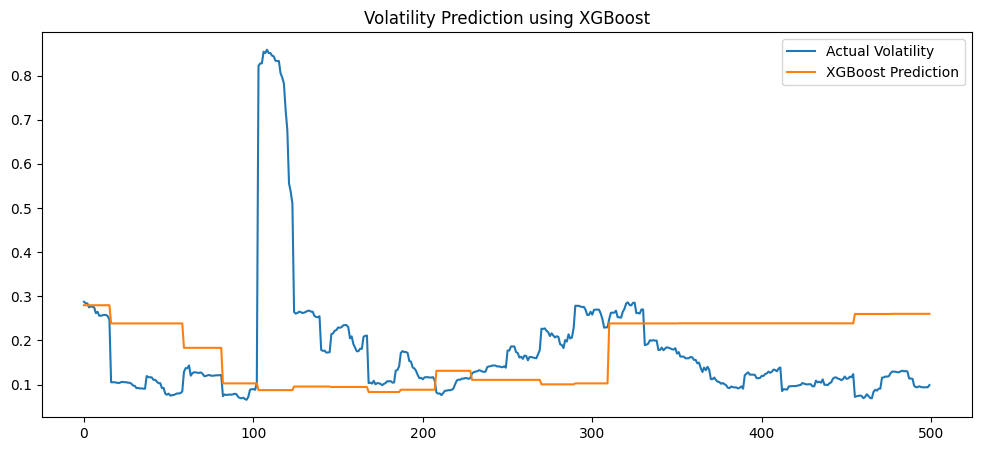

In [14]:
plt.figure(figsize=(12,5))
plt.plot(y_test.values, label="Actual Volatility")
plt.plot(y_pred_xgb, label="XGBoost Prediction")
plt.legend()
plt.title("Volatility Prediction using XGBoost")
plt.savefig("xgboost_volatility.png", dpi=300)
plt.show()


**7. Actual vs LSTM Prediction**

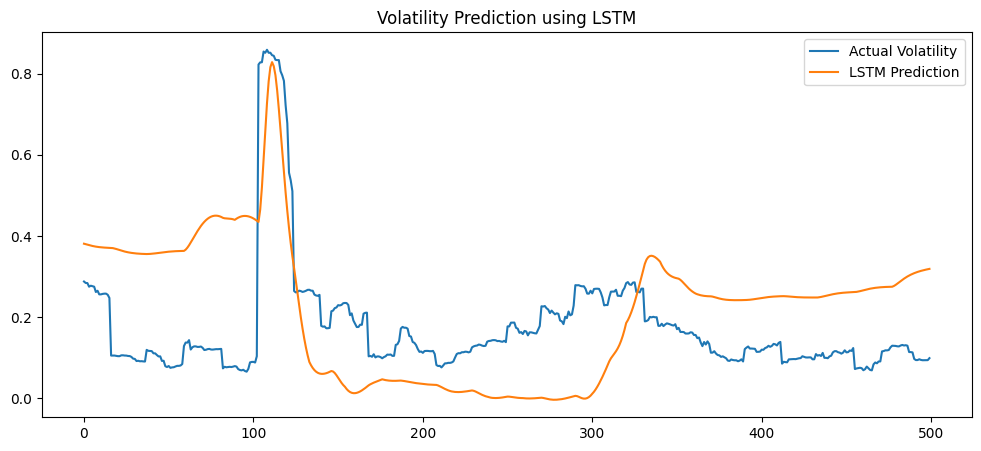

In [15]:
plt.figure(figsize=(12,5))
plt.plot(y_test_lstm, label="Actual Volatility")
plt.plot(y_pred_lstm, label="LSTM Prediction")
plt.legend()
plt.title("Volatility Prediction using LSTM")
plt.savefig("lstm_volatility.png", dpi=300)
plt.show()


**8. Model Comparison**

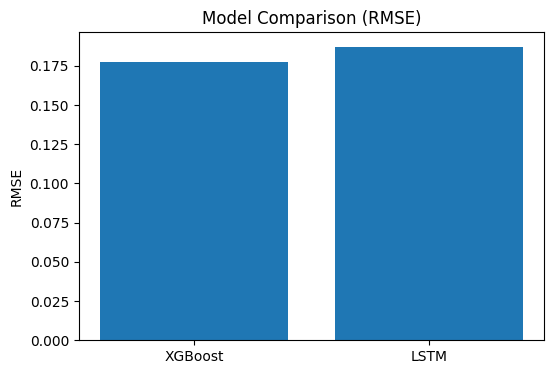

In [16]:
models = ['XGBoost', 'LSTM']
rmse_values = [rmse_xgb, rmse_lstm]

plt.figure(figsize=(6,4))
plt.bar(models, rmse_values)
plt.title("Model Comparison (RMSE)")
plt.ylabel("RMSE")
plt.savefig("model_comparison.png", dpi=300)
plt.show()


LSTM Training Loss Curve

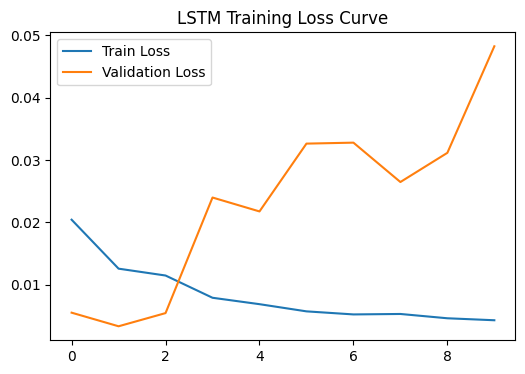

In [17]:
plt.figure(figsize=(6,4))
plt.plot(history.history['loss'], label="Train Loss")
plt.plot(history.history['val_loss'], label="Validation Loss")
plt.legend()
plt.title("LSTM Training Loss Curve")
plt.savefig("lstm_loss.png", dpi=300)
plt.show()


**9.GARCH MODEL **

In [18]:
returns = sp500['log_return_'] * 100  # GARCH prefers percentage returns
returns = returns.dropna()

In [19]:
garch = arch_model(returns, mean='Zero', vol='Garch', p=1, q=1)
garch_fit = garch.fit(disp="off")

print(garch_fit.summary())


                       Zero Mean - GARCH Model Results                        
Dep. Variable:            log_return_   R-squared:                       0.000
Mean Model:                 Zero Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -6685.52
Distribution:                  Normal   AIC:                           13377.0
Method:            Maximum Likelihood   BIC:                           13396.6
                                        No. Observations:                 5003
Date:                Sat, Apr 18 2026   Df Residuals:                     5003
Time:                        09:41:11   Df Model:                            0
                              Volatility Model                              
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
omega          0.0262  5.399e-03      4.851  1.228e-06 [1.

In [20]:
garch_forecast = garch_fit.conditional_volatility


In [21]:
garch_vol = garch_forecast.to_frame(name='GARCH_vol')
garch_vol = garch_vol.reindex(data.index)   # align dates

In [22]:
garch_train = garch_vol.iloc[:-500]
garch_test = garch_vol.iloc[-500:]


In [23]:
rmse_garch = np.sqrt(mean_squared_error(y_test, garch_test))
mae_garch = mean_absolute_error(y_test, garch_test)

print("GARCH RMSE:", rmse_garch)
print("GARCH MAE:", mae_garch)


GARCH RMSE: 0.9540895334879912
GARCH MAE: 0.844091536102854


**9. GARCH VOLATILITY FORECAST VS ACTUAL**

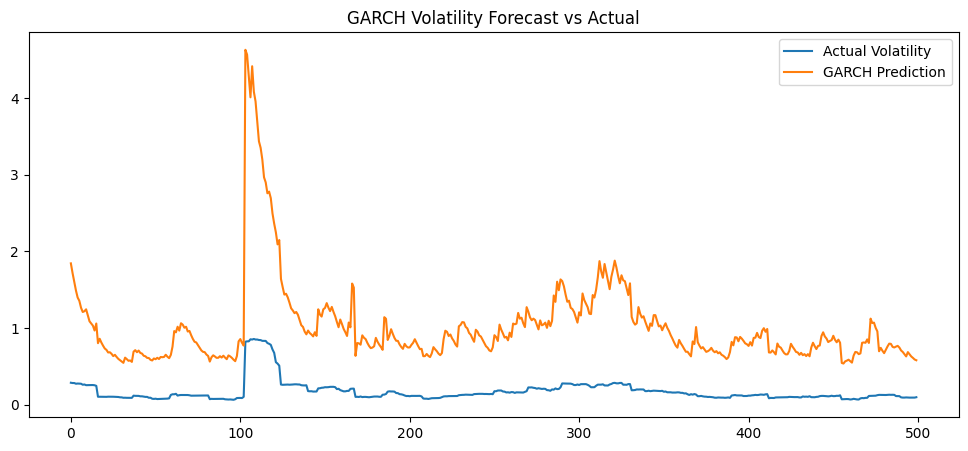

In [24]:
plt.figure(figsize=(12,5))
plt.plot(y_test.values, label="Actual Volatility")
plt.plot(garch_test.values, label="GARCH Prediction")
plt.legend()
plt.title("GARCH Volatility Forecast vs Actual")
plt.savefig("garch_volatility.png", dpi=300)
plt.show()


**10. Comparison of Three Models Used- GARCH, ML XGboost, and LSTM Deep Learning**

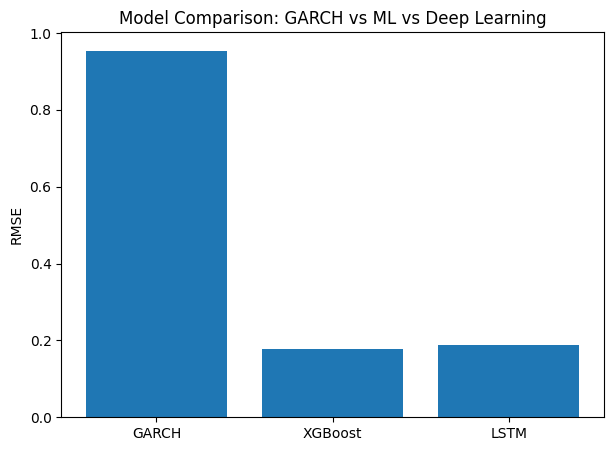

In [25]:
models = ['GARCH', 'XGBoost', 'LSTM']
rmse_all = [rmse_garch, rmse_xgb, rmse_lstm]

plt.figure(figsize=(7,5))
plt.bar(models, rmse_all)
plt.ylabel("RMSE")
plt.title("Model Comparison: GARCH vs ML vs Deep Learning")
plt.savefig("final_model_comparison.png", dpi=300)
plt.show()
